# Correlation and Regression

Complete this problem set with your group (up to 4 students). You can either hand-write your work and submit a hard copy, or go to File -> Download as HTML to generate an HTML file, then either submit it online or as a hard copy. Each group only needs to submit one copy and will receive the same grade. 

This team homework is based on Lecture 29: Correlation, Lecture 30: Regression and Lecture 31: Least Squares. 

**Helpful Resource:**
- [Python Reference](http://data8.org/sp22/python-reference.html): Cheat sheet of helpful array & table methods used in Data 8!

**Recommended Readings**: 
- [Correlation](https://inferentialthinking.com/chapters/15/1/Correlation.html)
- [Regression Line](https://inferentialthinking.com/chapters/15/2/Regression_Line.html)
- [Least Squares](https://inferentialthinking.com/chapters/15/4/Least_Squares_Regression.html)

In [1]:
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np
from math import ceil

### Scatterplots

Consider the car data given in the file. An explanation of some of the varibles:

	Weight	= Weight of the car (in pounds)
	CityMPG = EPA's estimated miles per gallon for city driving
	FuelCap	= Size of the gas tank (in gallons)
	QtrMile	= Time (in seconds) to go 1/4 mile from a standing start
	Acc060	= Time (in seconds) to accelerate from zero to 60 mph
	PageNum	= Page number on which the car appears in the buying guide


Use `cars.scatter` to find pairs of variables that show

1. a strong positive association
2. a strong negative association
3. a weak positive association
4. a weak negative association
5. almost no association 

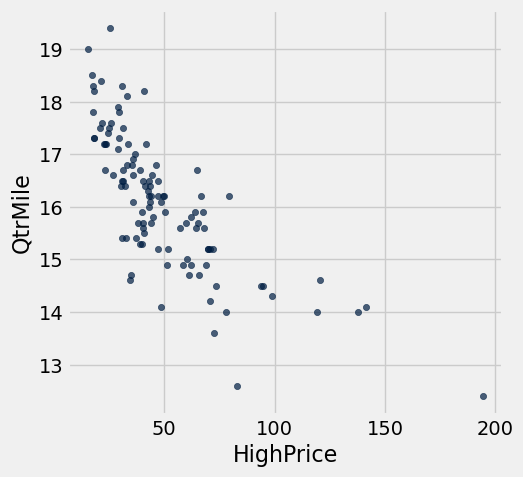

In [2]:
cars = Table().read_table('Cars2015.csv')
cars.sort('CityMPG', descending=True)
cars.scatter('HighPrice', 'QtrMile') # example of a strong positive correlation

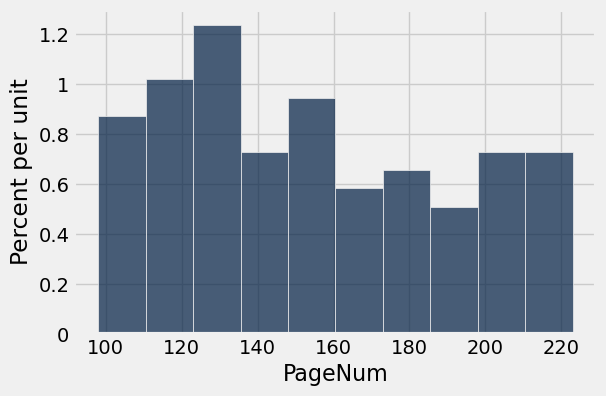

In [3]:
cars.hist('PageNum')

### Correlation 

The following code was taken from the textbook [15.1: Correlation](https://inferentialthinking.com/chapters/15/1/Correlation.html). It calculates the r value for each pair of variables by first converting the X and Y values to standard units. Using mathematical notation this means: 

$r = \frac{\sum Z_x \cdot Z_y}{n}$

In [4]:
x = make_array(0, 1, 2)
y = make_array(6, 4, 1)
zx = (x - np.average(x)) / np.std(x)
zy = (y - np.average(y)) / np.std(y)
sum(zx * zy) / 3

-0.99339926779878274

In [5]:
def standard_units(any_numbers):
    return (any_numbers - np.mean(any_numbers))/np.std(any_numbers)  

def correlation(t, xlabel, ylabel):
    return np.mean(standard_units(t.column(xlabel))*standard_units(t.column(ylabel)))


In [6]:
print("strong positive", correlation(cars, 'CityMPG', 'HwyMPG'))
print("no correlation", correlation(cars, 'Weight', 'PageNum'))

strong positive 0.934064352949
no correlation -0.203627772877


Use `correlation` function to compute $r$ for each pair of variables you listed above. Using the numbering (1-5) above, list these five pairs in ascending order. 

In [7]:
print("strong negative correlation", correlation(cars, 'HighPrice', 'QtrMile'))

strong negative correlation -0.756651255349


### Regression 

The regression equation requires two parameters: slope ($m$) and intercept ($b$).

The formulas for computing the slope and intercept are both based on the correlation coefficient $r$ computed above: 

$m = r \cdot \frac{SD_y}{SD_x}$

$b = \bar{y} - m\bar{x}$ 

where $\bar{y}$ and $\bar{x}$ are the means of x and y values, respectively. 

Based on the `correlation` function described above, the following code computes the slope and intercept of the regression line. 

In [8]:
x = make_array(0, 1, 2)
y = make_array(6, 4, 2)
zx = (x - np.average(x)) / np.std(x)
zy = (y - np.average(y)) / np.std(y)
r = np.average(zx * zy)
m = r*np.std(y)/np.std(x)
b = np.average(y) - m*np.average(x)
m, b

(-1.9999999999999998, 6.0)

In [9]:
def slope(t, label_x, label_y):
    r = correlation(t, label_x, label_y)
    return r*np.std(t.column(label_y))/np.std(t.column(label_x))

def intercept(t, label_x, label_y):
    return np.mean(t.column(label_y)) - slope(t, label_x, label_y)*np.mean(t.column(label_x))

Based on the slope and intercept, the following code plots the regression line with the scatter plot. 

In [10]:
def scatter_with_regression_line(table, xlabel, ylabel):
    m = slope(table, xlabel, ylabel) 
    b = intercept(table, xlabel, ylabel)
    table.scatter(xlabel, ylabel)
    xmin = np.min(table.column(xlabel))
    xmax = np.max(table.column(xlabel))
    xlimits = np.array([xmin, xmax])
    plots.plot(xlimits, m*xlimits + b)
    return (m, b)


Use the code provided above to compute the regression line that predicts the CityMPG (Y) from the Weight (X) of the vehicle. 

regression model: y= -0.000824799955235 *x +  11.1094533551


-0.43491635927603073

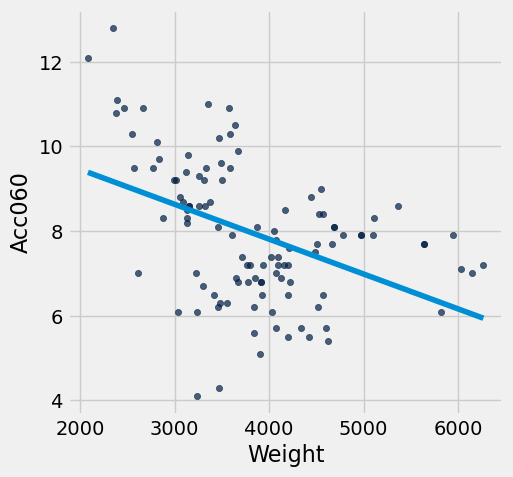

In [11]:
m, b= scatter_with_regression_line(cars, 'Weight', 'Acc060')
print("regression model: y=", m, "*x + ", b)
correlation(cars, 'Weight', 'Acc060')

regression model: y= -229.331049748 *x +  5666.26308668
r^2 0.189152239566
m*m 0.18915223956614596


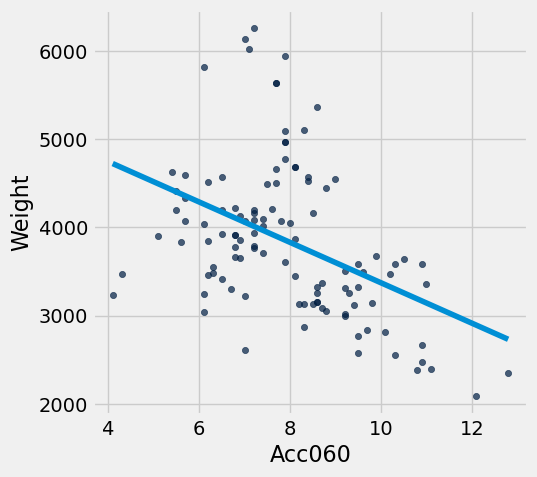

In [26]:
m, b= scatter_with_regression_line(cars, 'Acc060', 'Weight')
print("regression model: y=", m, "*x + ", b)
print("r^2", correlation(cars, 'Acc060', 'Weight')**2)

print('m*m', -0.000824799955235 * (-229.331049748))

regression model: y= -0.000876483923041 *x +  11.3854487387


(-0.43491635927603073, -0.43491635927603073)

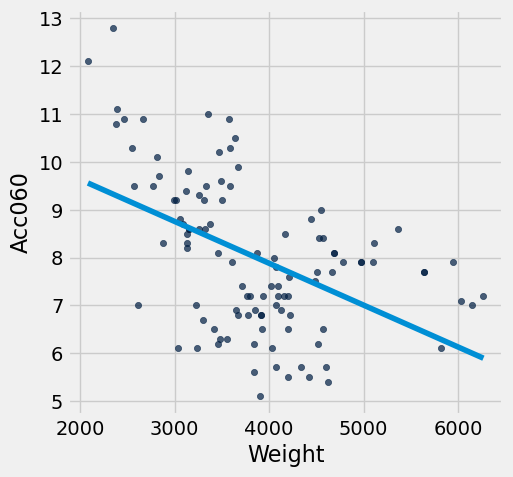

In [22]:
m, b= scatter_with_regression_line(cars.where('Acc060',are.above(5)), 'Weight', 'Acc060')
print("regression model: y=", m, "*x + ", b)
correlation(cars, 'Weight', 'Acc060'), correlation(cars, 'Acc060', 'Weight') 

Identify two cars from the scatter plot that appear to have the largest prediction errors (also called the *residual*) in absolute value. What are their make and model? You may want to review `Table.where` and the predicates in the [Python Reference](https://www.data8.org/sp22/python-reference.html) 

In [13]:
cars

Make,Model,Type,LowPrice,HighPrice,Drive,CityMPG,HwyMPG,FuelCap,Length,Width,Wheelbase,Height,UTurn,Weight,Acc030,Acc060,QtrMile,PageNum,Size
Chevrolet,Spark,Hatchback,12.27,25.56,FWD,30,39,9,145,63,94,61,34,2345,4.4,12.8,19.4,123,Small
Hyundai,Accent,Hatchback,14.745,17.495,FWD,28,37,11.4,172,67,101,57,37,2550,3.7,10.3,17.8,148,Small
Kia,Rio,Sedan,13.99,18.29,FWD,28,36,11.3,172,68,101,57,37,2575,3.5,9.5,17.3,163,Small
Mitsubishi,Mirage,Hatchback,12.995,15.395,FWD,37,44,9.2,149,66,97,59,32,2085,4.4,12.1,19,188,Small
Nissan,Versa Note,Hatchback,14.18,17.96,FWD,31,40,10.9,164,67,102,61,37,2470,4,10.9,18.2,196,Small
Dodge,Dart,Sedan,16.495,23.795,FWD,23,35,14.2,184,72,106,58,38,3260,3.4,9.3,17.2,128,Small
Chevrolet,Cruze LS,Sedan,16.17,25.66,FWD,24,36,15.6,181,71,106,58,38,3140,3.7,9.8,17.6,119,Small
Fiat,500L,Hatchback,19.345,24.695,FWD,24,33,13.1,167,70,103,66,37,3330,3.9,9.5,17.4,131,Small
Ford,Focus,Hatchback,17.17,29.17,FWD,28,38,12.4,179,72,104,58,39,2990,3.4,9.2,17.1,136,Small
Toyoto,Yaris,Hatchback,14.845,17.629,FWD,30,35,11.1,154,67,99,59,34,2385,3.9,10.8,18.3,216,Small


Using the Weight of the vehicle as the X-coordinate, and residual as the Y-coordinate, create the so-called ```residual plot``` for the same problem of predicting City MPG from Weight of the vehicle. Where are the two cars that you found above in the residual plot? 

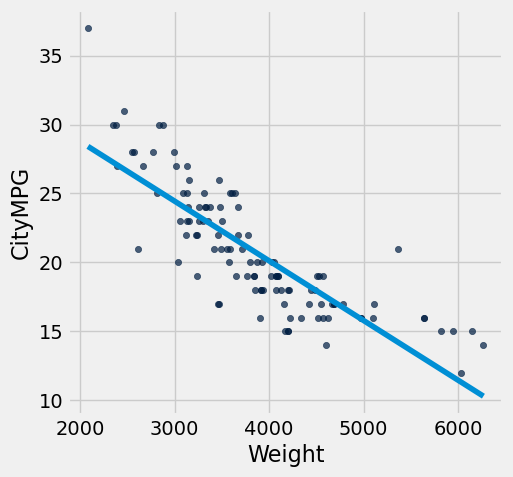

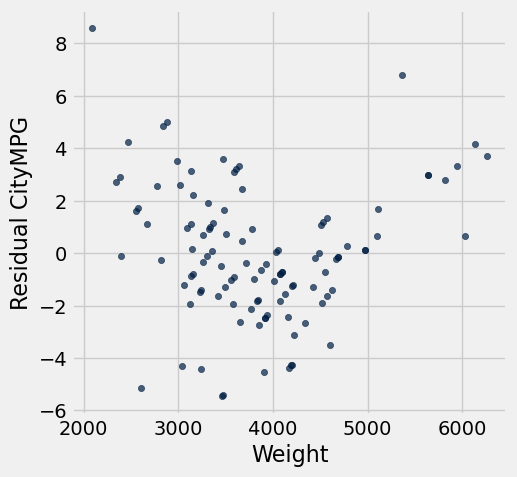

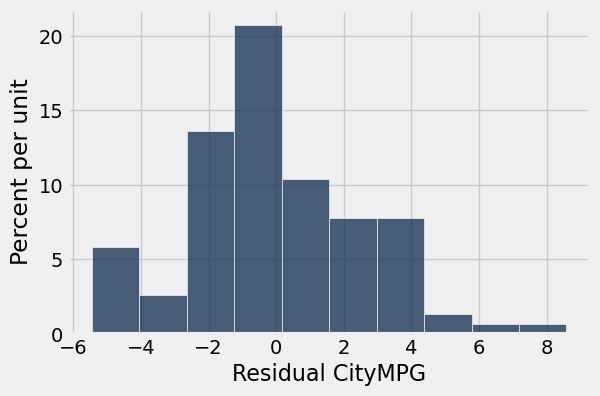

In [35]:
m, b = scatter_with_regression_line(cars, 'Weight', 'CityMPG')
correlation(cars, 'Weight', 'CityMPG')
predictedMPG = m*cars.column('Weight') + b
cars.with_column('Predicated CityMPG', predictedMPG)
cars_with_residual = cars.with_column('Residual CityMPG', cars.column('CityMPG') - predictedMPG)
cars_with_residual.scatter('Weight', 'Residual CityMPG')
cars_with_residual.hist('Residual CityMPG')

In [36]:
np.average(cars_with_residual.column('Residual CityMPG')), np.std(cars_with_residual.column('Residual CityMPG'))

(3.1974423109204509e-15, 2.5447208388635256)

### Model Fitting by using `minimize`

The following code demonstrates how to use the `minimize` function to fit models to a set of data. It accepts a loss function as input, and outputs the parameters that result in the minimum loss for the function. For example, in the code shown below, `linear_fit` computes the loss of a linear function $y=mx+b$ fitted to the set of 5 points. Passing it as input to `minimize` returns the two parameters $m$ and $b$ necessary to specify the linear function. 

(1.0999999999999999, -0.69999999999999973)

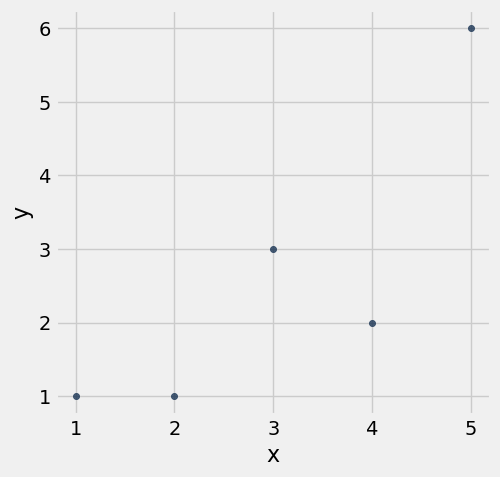

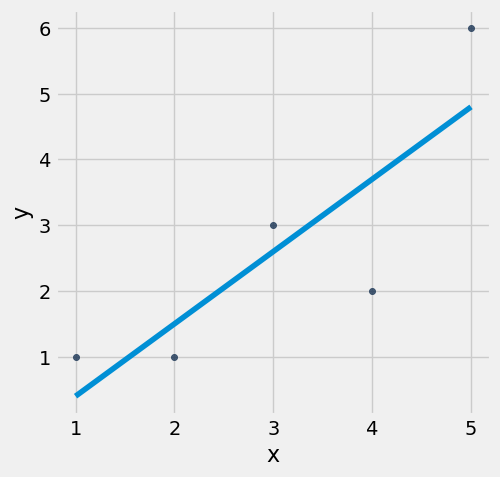

In [38]:
five_points = Table().with_columns('x', [1,2,3,4,5], 'y',[1, 1, 3, 2, 6])
five_points.scatter('x', 'y')
scatter_with_regression_line(five_points, 'x', 'y')

In [41]:
def linear_fit(m, b):
    errors = five_points.column('y') - (m*five_points.column('x') + b)
    return np.sum((errors)**2)

linear_fit(1, 1)
m, b = minimize(linear_fit)
m, b

(1.1037943711302989, -0.7554848944584851)

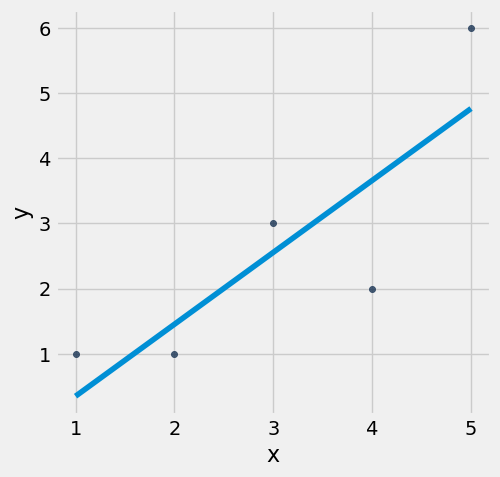

In [42]:
five_points.scatter('x', 'y')
xlimits = np.array([1, 5])
plots.plot(xlimits, m*xlimits + b)

Change the code so that the loss function calculates the square root of the sum of errors. Did this change the fitted model in any way? 

best linear fit: 4.44410178107
y= 0.238048989108 *x^2+ 0.000317522628934 *x+ 0.0471876591591
best quadratic fit: 3.38112493634


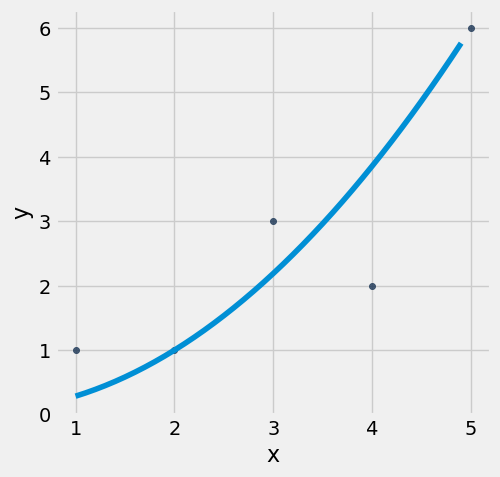

In [52]:
def quadratic_fit(a, b, c):
    errors = five_points.column('y') - (a*(five_points.column('x')**2) + b*five_points.column('x') + c)
    return np.sum(abs(errors))
print("best linear fit:", quadratic_fit(0, 1.1037943711302989, -0.7554848944584851))
a, b, c = minimize(quadratic_fit)
print("y=", a, "*x^2+", b, "*x+", c)
print("best quadratic fit:", quadratic_fit(a, b, c)) 
five_points.scatter('x', 'y')
def quadratic_y(x, a, b, c):
    return a*(x**2) + b*x + c

x = np.arange(1, 5, 0.1)
plots.plot(x, quadratic_y(x, a, b, c))

Change the code again so that the loss function calculates the sum of absolute values of errors. Did this change the model? 

A quadratic model uses 3 parameters to fit the data: $y = ax^2 + bx + c$. Run the following code and evaluate the residual of the model returned by `minimize`. How does this residual compare with the least squares linear model? 

(0.23804898910777028, 0.00031752262893354949, 0.047187659159125074)

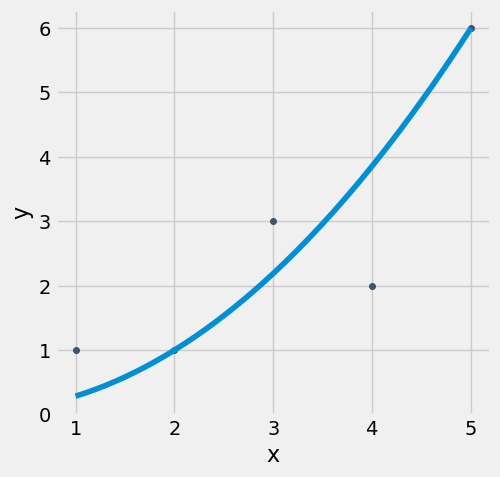

In [56]:
def quadratic_fit(a, b, c):
    x = five_points.column('x')
    errors = five_points.column('y') - (a*(x**2) + b*x + c)
    return np.sum(abs(errors))

a, b, c = minimize(quadratic_fit)
five_points.scatter('x', 'y')
xlimits = np.arange(1, 5.1, 0.1)
plots.plot(xlimits, a*xlimits**2 + b*xlimits + c)
a, b, c

Modify the code so that it fits a cubic model which uses 4 parameters: $ y = ax^3 + bx^2 + cx + d$. How does the residual of the cubic model compare with the quadratic one? 

(0.042789259467341731,
 -0.00032242785987576062,
 5.3981165482280792e-06,
 0.65937627249611352)

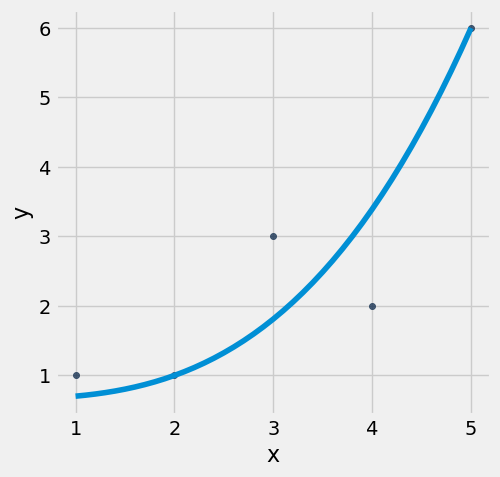

In [57]:
def cubic_fit(a, b, c, d):
    x = five_points.column('x')
    errors = five_points.column('y') - (a*(x**3) + b*(x**2) + c*x + d)
    return np.sum(abs(errors))

a, b, c, d = minimize(cubic_fit)
five_points.scatter('x', 'y')
xlimits = np.arange(1, 5.1, 0.1)
plots.plot(xlimits, a*xlimits**3 + b*xlimits**2 + c*xlimits + d)
a, b, c, d

In mathematics, quadratic and cubic models are members of the general polynomial family. What happens to the residual of the best fit model if you keep increasing the number of parameters? Show this through an experiment. Is this a good idea? 

Suppose you randomly sample 4 points from the ```five_points``` data set, and fit the cubic model above via ```minimize```. What would happen to the prediction error for the point that is left out? Run the simulation a few times to observe what happens. 

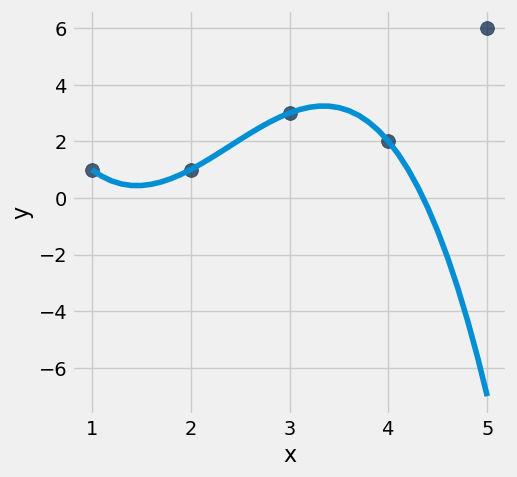

In [68]:
four_points = five_points.sample(4, with_replacement=False)

# re-use the cubic_fit function from above, but define the error function over the four points randomly chosen above.
def cubic_fit_with_4(a, b, c, d):
    x = four_points.column('x')
    errors = four_points.column('y') - (a*(x**3) + b*(x**2) + c*x + d)
    return np.sum((errors)**2)

a, b, c, d = minimize(cubic_fit_with_4)

five_points.scatter('x', 'y', s=100)
xlimits = np.arange(1, 5.1, 0.1)
plots.plot(xlimits, a*xlimits**3 + b*xlimits**2 + c*xlimits + d)